# Problem 1

Comments in `__init__` describe the various layers.
Comments in `forward` describe how the layers operate together.

In [1]:
import torch.nn as nn

class WaveNet(nn.Module):
    def __init__(self, quantization_channels=256, residual_channels=32, skip_channels=32, dilation_depth=2, filter_size=2):
        super(WaveNet, self).__init__()
        
        self.quantization_channels = quantization_channels
        self.residual_channels = residual_channels
        self.skip_channels = skip_channels
        self.dilation_depth = dilation_depth
        self.filter_size = filter_size
        
        # Initial causal 1D convolution
        # Type: Causal Conv1D
        # Size: in_channels=256, out_channels=32, kernel_size=2, padding=1
        # Function: projects input sequence into the residual channel and
        # prevents access to future samples.
        self.causal_conv = nn.Conv1d(
            in_channels=quantization_channels,
            out_channels=residual_channels,
            kernel_size=filter_size,
            padding=filter_size - 1
        )
        
        self.dilated_convs = nn.ModuleList()
        self.residual_convs = nn.ModuleList()
        self.skip_convs = nn.ModuleList()
        
        for i in range(dilation_depth):
            dilation = 2 ** i
            padding = (filter_size - 1) * dilation

            # Dilated filter convolution
            # Type: Dilated Conv1D (filter)
            # Size: in_channels=32, out_channels=32, kernel_size=2, dilation=2^i, padding=(2-1)*2^i
            # Function: computes the tanh filter output for the activation unit,
            # expanding the receptive field without greatly increasing depth.
            conv_filter = nn.Conv1d(
                in_channels=residual_channels,
                out_channels=residual_channels,
                kernel_size=filter_size,
                dilation=dilation,
                padding=padding
            )
            
            # Dilated gate convolution
            # Type: Dilated Conv1D (gate)
            # Size: in_channels=32, out_channels=32, kernel_size=2, dilation=2^i, padding=(2-1)*2^i
            # Function: computes the sigmoid gate that controls how much information
            # from the filter branch is passed forward in the activation unit.            
            conv_gate = nn.Conv1d(
                in_channels=residual_channels,
                out_channels=residual_channels,
                kernel_size=filter_size,
                dilation=dilation,
                padding=padding
            )

            # Apppends the filter and gate as a pair to the dilated convolutions
            self.dilated_convs.append(nn.ModuleList([conv_filter, conv_gate]))

            # Residual 1x1 convolution
            # Type: Conv1D / Residual connection
            # Size: in_channels=32, out_channels=32, kernel_size=1
            # Function: maps the activation back into the residual stream so it
            # can be added to the block input, mitigating the vanishing gradient problem.
            self.residual_convs.append(nn.Conv1d(
                in_channels=residual_channels,
                out_channels=residual_channels,
                kernel_size=1
            ))

            # Skip 1x1 convolution
            # Type: Conv1D / Skip connection
            # Size: in_channels=32, out_channels=32, kernel_size=1
            # Function: sends each block’s output to the global skip pathway, so features
            # from all dilation levels can bypass intermediate layers to contribute directly 
            # to the final output.
            self.skip_convs.append(nn.Conv1d(
                in_channels=residual_channels,
                out_channels=skip_channels,
                kernel_size=1
            ))
        
        # Rectified linear unit, negative values become 0, positive values stay the same
        # applies before the final output layers, helping the model maintain more complex 
        # relationships 
        self.relu = nn.ReLU()


        # First output projection
        # Type: Conv1D / Output
        # Size: in_channels=32, out_channels=32, kernel_size=1
        # Function: further transforms the aggregated skip features before the final
        # classification layer.
        self.output_conv1 = nn.Conv1d(
            in_channels=skip_channels,
            out_channels=skip_channels,
            kernel_size=1
        )

        # Final output projection
        # Type: Pointwise Conv1D / Output
        # Size: in_channels=32, out_channels=256, kernel_size=1
        # Function: converts the hidden skip representation into logits over the
        # 256 quantized output classes for next-sample prediction.
        self.output_conv2 = nn.Conv1d(
            in_channels=skip_channels,
            out_channels=quantization_channels,
            kernel_size=1
        )
    
    def forward(self, x):
        # input x shape: (batch_size, seq_len)
        x = F.one_hot(x, num_classes=self.quantization_channels).float()
        # reshape x to (batch_size, channels, seq_len)
        x = x.transpose(1, 2)

        # Initial causal convolution to project input into residual channel space
        x = self.causal_conv(x)
        x = x[:, :, :- (self.filter_size - 1)]  # Remove padding to make causal
        skip_connections = []
        
        for i in range(self.dilation_depth):
            # Retrieve filter and gate convolutions for this layer
            conv_filter, conv_gate = self.dilated_convs[i]

            # Apply dilated convolutions
            filter_out = conv_filter(x)
            gate_out = conv_gate(x)

            # Remove padding to maintain causality
            pad = (self.filter_size - 1) * (2 ** i)
            filter_out = filter_out[:, :, :-pad]
            gate_out = gate_out[:, :, :-pad]

            # Gated activation unit: tanh (filter) × sigmoid (gate)
            # Controls information flow through the network
            tanh_out = torch.tanh(filter_out)
            sigmoid_out = torch.sigmoid(gate_out)
            z = tanh_out * sigmoid_out
            
            # Skip connection: contributes directly to final output
            skip = self.skip_convs[i](z)
            skip_connections.append(skip)
    
            # Residual connection: added back to input for stablity, i.e., mitigate vanishing gradients
            res = self.residual_convs[i](z)
            x = x + res
            
        # Combine all skip connections from the different dilations
        out = sum(skip_connections)

        # Nonlinear transformation of aggregated features
        out = self.relu(out)
        out = self.output_conv1(out)
        out = self.relu(out)

        # Project to logits over quantized output space (256 classes)
        out = self.output_conv2(out)

        # Collapse time dimension (global average pooling)
        out = out.mean(dim=2)

        # Convert logits to probability distribution over next sample values
        out = F.softmax(out, dim=1)
        return out

## Problem 2

The code in the transcriber_notebook is a classifier that maps waveforms to note labels. Below, we swap this, creating a generator that takes a note label, e.g., `A#4`, as input and produces a waveform sequence, e.g., `sine wave of 466.16 Hz`, as output. 

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 72
import numpy as np

import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

Device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f'PyTorch version= {torch.__version__}')
print(f'torchaudio version= {torchaudio.__version__}')
print(f'CUDA available= {torch.cuda.is_available()}')

PyTorch version= 2.10.0
torchaudio version= 2.10.0
CUDA available= False


Below we: 
- Modify the DataSet to use note indexes as the data and sine waves as the labels so the model learns note -> waveform
- Introduce an embedding layer for the notes at input which is a better representation than the integer index of the note
- Add a transformer encoder and decoder to the `__init__` method to give the model a seq-to-seq structure
- Update the input and output sequences' input dimensions. This is done through the embedding layer for notes and outputting sequences of length SEQ_LEN for the waveforms
- Initialize the decoder input with all zeros or one of the embeddings learned
- Use MSELoss() for the decoder and optimization. This is needed because the model now predicts continuous waveform amplitudes rather than discrete classes, so mean squared loss is more appropriate than the classifier. Mean squared loss measures how close the predicted waveform values are to the true sine-wave values. 

After the changes above, I experimented with sequence length and the number of epochs. Sequence length seemed to impact low frequency notes like C2 the most which had lower accuracy at shorter sequence lengths. I think this is because the longer sequence length allows the model to see more sine periods. Increasing the number of epochs helped smoothed out the predicted curves. Increasing both of course led to longer training times. I found the best results with reasonable training times (~5 min) to be achieved at sequence length 100 with 200 epochs of training.

In [3]:
# notes
Note_Freqs = {
 'C2': 65.41, 'C#2': 69.3, 'D2': 73.42, 'D#2': 77.78, 'E2': 82.41, 'F2': 87.31,
 'F#2': 92.5, 'G2': 98.0, 'G#2': 103.83, 'A2': 110.0, 'A#2': 116.54, 'B2': 123.47,
 'C3': 130.81, 'C#3': 138.59, 'D3': 146.83, 'D#3': 155.56, 'E3': 164.81, 'F3': 174.61,
 'F#3': 185.0, 'G3': 196.0, 'G#3': 207.65, 'A3': 220.0, 'A#3': 233.08, 'B3': 246.94,
 'C4': 261.63, 'C#4': 277.18, 'D4': 293.66, 'D#4': 311.13, 'E4': 329.63, 'F4': 349.23,
 'F#4': 369.99, 'G4': 392.0, 'G#4': 415.3, 'A4': 440.0, 'A#4': 466.16, 'B4': 493.88,
 'C5': 523.25, 'C#5': 554.37, 'D5': 587.33, 'D#5': 622.25, 'E5': 659.25, 'F5': 698.46,
 'F#5': 739.99, 'G5': 783.99, 'G#5': 830.61, 'A5': 880.0, 'A#5': 932.33, 'B5': 987.77,
 'C6': 1046.5, 'C#6': 1108.73, 'D6': 1174.66, 'D#6': 1244.51, 'E6': 1318.51, 'F6': 1396.91,
 'F#6': 1479.98, 'G6': 1567.98, 'G#6': 1661.22, 'A6': 1760.0, 'A#6': 1864.66, 'B6': 1975.53,
 'C7': 2093.0, 'C#7': 2217.46, 'D7': 2349.32, 'D#7': 2489.02, 'E7': 2637.02, 'F7': 2793.83,
 'F#7': 2959.96, 'G7': 3135.96, 'G#7': 3322.44, 'A7': 3520.0, 'A#7': 3729.31, 'B7': 3951.07
}

Notes = list(Note_Freqs.keys())  # labels - notes

# Reverse the dictionary for easier lookups
Freq_Notes = {v: k for k, v in Note_Freqs.items()}

Freqs = list(Freq_Notes.keys())

SEQ_LEN=100

# input is a note id, output is waveform
class FreqDataset(Dataset):
    def __init__(self, n_samples=512, seq_len=SEQ_LEN):
        self.data, self.labels = [], []
        for _ in range(n_samples):
            freq = np.random.choice(Freqs)  # randomly generate signals
            note = Freq_Notes[freq]
            x = np.arange(seq_len)
            sine_wave = np.sin(2 * np.pi * freq * x / 10000)

            self.data.append(torch.tensor(Notes.index(note), dtype=torch.long))
            self.labels.append(torch.tensor(sine_wave, dtype=torch.float32))

        self.data = torch.stack(self.data)
        self.labels = torch.stack(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

class NoteGenerator(nn.Module):
    def __init__(self, input_dim=1, model_dim=16, nhead=2, n_decoder_layers=1, n_classes=len(Notes), seq_len=SEQ_LEN):
        super().__init__()
        self.seq_len = seq_len
        self.model_dim = model_dim

        # embedding layer for the notes at input
        self.note_embedding = nn.Embedding(n_classes, model_dim)

        self.pos_encoding = nn.Parameter(torch.randn(seq_len, model_dim) * 0.02)

        # decoder input 
        self.decoder_input_proj = nn.Linear(1, model_dim)

        # transformer decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=model_dim,
            nhead=nhead,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_decoder_layers)

        # output projection
        self.output_proj = nn.Linear(model_dim, 1)

    def forward(self, note_ids):
        batch_size = note_ids.size(0)

        # encoder memory from note embedding
        memory = self.note_embedding(note_ids).unsqueeze(1)

        # initialize decoder input with zeros
        decoder_input = torch.zeros(batch_size, self.seq_len, 1, device=note_ids.device)

        # decoder input to model_dim and add positional encoding
        tgt = self.decoder_input_proj(decoder_input)
        tgt = tgt + self.pos_encoding.unsqueeze(0)

        # decode waveform sequence conditioned on note embedding
        decoded = self.decoder(tgt=tgt, memory=memory)

        # map each decoded position to one waveform value
        out = self.output_proj(decoded).squeeze(-1)
        return out

def train(_model, _dataloader, epochs=20, lr=0.001, info=False):
    import sys
    optimizer = optim.Adam(_model.parameters(), lr=lr)

    # Use MESLoss to measure mean squared error which is more appropriate for sine waves
    criterion = nn.MSELoss()

    for e in range(epochs):
        totloss = 0
        for x, y in _dataloader:
            optimizer.zero_grad()
            out = _model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            totloss += loss.item()
        
        if info:
            sys.stderr.write(f"\r{e+1:3d}/{epochs:3d} | Loss: {totloss:3.3f}")
            sys.stderr.flush()


# generation function, given a note predict the sine wave
def predict(model, note_name):
    model.eval()
    with torch.no_grad():
        note_id = torch.tensor([Notes.index(note_name)], dtype=torch.long)
        wav = model(note_id).squeeze(0)
    return wav


# dataset
ds_freqs = FreqDataset(n_samples=1024)  # there will be repeats
Dloader = DataLoader(ds_freqs, batch_size=32, shuffle=False)

In [4]:
note_id = ds_freqs[0][0]
print(Notes[note_id])    

C6


In [5]:
Model = NoteGenerator()

In [6]:
%%time

train(Model, Dloader, epochs=200, info=True)

200/200 | Loss: 2.9347

CPU times: user 10min 26s, sys: 2min 8s, total: 12min 34s
Wall time: 5min 13s


Note: B4
Pred: [ 0.041  0.365  0.42   0.909  0.957  0.973  0.646  0.867  0.772  0.244
 -0.459 -0.492 -0.617 -0.933 -0.89  -0.795 -0.762 -0.787 -0.447 -0.365
 -0.155  0.306  0.636  0.753  0.828  0.971  1.055  0.614  1.027  0.254
  0.463  0.163  0.161  0.012 -0.633 -0.914 -0.937 -0.88  -0.472 -0.508
 -0.295  0.325  0.558  0.672  0.573  0.912  0.991  0.016  0.786  0.847
 -0.149  0.228 -0.388 -0.579 -0.295  0.069 -0.795 -0.811 -0.471 -0.234
 -0.469 -0.31   0.212  0.708  0.216  0.623  0.936  0.521  0.696 -0.099
  0.124 -0.367 -0.865 -0.973 -0.432 -0.923 -0.516 -0.957 -0.669 -0.915
 -0.418 -0.353  0.36   0.573  0.735  0.138  0.159  0.8    0.293  0.769
  0.715  0.455 -0.337 -0.562 -0.499 -0.812 -0.758 -0.991 -0.89  -0.862]
Orig: [ 0.     0.305  0.582  0.802  0.946  1.     0.958  0.825  0.612  0.342
  0.038 -0.269 -0.55  -0.779 -0.933 -0.998 -0.968 -0.846 -0.642 -0.378
 -0.077  0.231  0.517  0.754  0.919  0.995  0.977  0.866  0.671  0.413
  0.115 -0.194 -0.484 -0.728 -0.903 -0.991 -0.985 -0.88

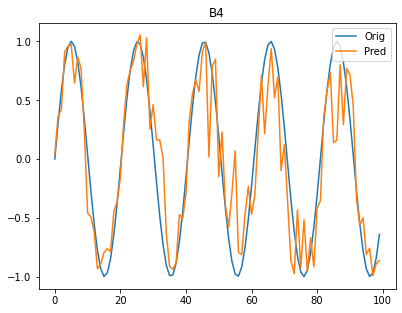

Note: C#4
Pred: [ 0.007  0.204  0.636  0.531  0.64  -0.094  0.806  0.929  0.951  0.97
  0.902  0.852  0.631  0.711  0.687  0.424  0.298  0.365  0.25  -0.041
  0.385 -0.824 -0.651 -0.766 -0.146 -1.031 -0.936 -0.996 -0.904 -0.954
 -0.921 -0.636 -0.339 -0.446 -0.712 -0.332 -0.465  0.493  0.089  0.588
 -0.385  0.545  0.881  0.749  0.899  1.019  0.797  0.95   0.711  0.82
 -0.136  0.568  0.692 -0.231  0.089 -0.318  0.073  0.015 -0.689 -0.823
 -0.695 -0.777 -0.731 -0.985 -0.88  -0.956 -0.705 -0.648 -0.753 -0.749
 -0.242 -0.05   0.065  0.361  0.278  0.162  0.73   0.798  0.917  0.965
  0.987  0.809 -0.103  0.898  0.855  0.824  0.633  0.27   0.64   0.297
  0.225 -0.119 -0.418 -0.121 -0.209 -0.397 -1.029 -0.766 -0.852 -0.936]
Orig: [ 0.     0.173  0.341  0.499  0.642  0.765  0.865  0.939  0.984  1.
  0.985  0.941  0.868  0.769  0.647  0.505  0.348  0.18   0.007 -0.167
 -0.335 -0.493 -0.636 -0.76  -0.861 -0.936 -0.983 -1.    -0.987 -0.943
 -0.872 -0.773 -0.652 -0.511 -0.354 -0.187 -0.014  0.16   0

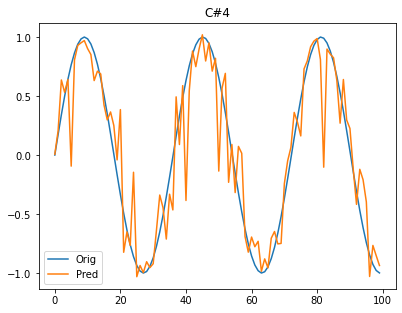

Note: C4
Pred: [ 0.024  0.16   0.651  0.504  0.673  0.611  0.904  0.768  0.796  0.762
  1.061  0.983  0.909  0.783  0.78   0.385  0.543  0.485  0.316  0.128
  0.408 -0.245 -0.301 -0.579 -0.645 -0.945 -0.805 -0.791 -1.076 -1.157
 -0.807 -1.054 -0.81  -0.652 -0.63  -0.241 -0.426 -0.091 -0.272  0.236
  0.314  0.7   -0.073  0.709  0.829  0.917  0.818  0.92   0.946  0.938
  0.724  0.627  0.844  0.693  0.724  0.337  0.326  0.197 -0.038 -0.238
 -0.604 -0.67  -0.801 -0.415 -0.684 -0.959 -0.695 -0.775 -0.724 -0.752
 -0.991 -0.533 -0.448 -0.924 -0.754  0.035  0.226  0.051  0.077  0.226
  0.718  0.655  0.554  0.842  0.588  0.907  0.623  0.81   0.859  0.83
  0.785  0.68   0.385  0.265  0.026  0.2   -0.17   0.223 -0.072 -0.105]
Orig: [ 0.     0.164  0.323  0.473  0.611  0.732  0.834  0.913  0.967  0.996
  0.997  0.972  0.92   0.844  0.745  0.626  0.489  0.34   0.182  0.018
 -0.146 -0.306 -0.457 -0.597 -0.72  -0.824 -0.905 -0.963 -0.994 -0.998
 -0.976 -0.927 -0.854 -0.757 -0.64  -0.505 -0.357 -0.2  

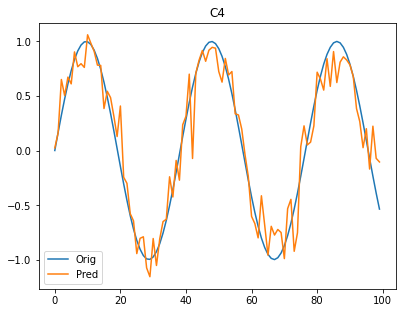

Note: A#7
Pred: [-0.002  0.469 -1.388  0.492  0.142 -0.819 -0.207  0.289 -0.053  0.655
 -0.898  0.209  0.094  0.048  0.68  -0.321 -0.285  0.599 -0.494  0.217
 -0.44   0.233  0.642 -0.382 -0.649  0.194 -0.567  0.068  0.295 -1.11
  0.237 -0.76  -0.211  0.424 -0.41   0.485  0.399 -0.781  0.14  -0.165
 -0.502  0.861 -0.765  0.013  0.232 -0.665  0.707 -0.195 -0.037  0.641
 -0.6    0.146  0.385 -0.508  0.681 -0.308 -0.804  0.956 -0.578  0.61
  0.591 -0.83   0.791  0.081 -0.163 -0.376 -0.158 -0.276  0.044 -0.378
 -0.342  0.336 -0.585 -0.171 -0.597 -0.55   0.696 -0.624  0.406 -0.524
 -0.111  0.696 -0.409 -0.37   0.293 -0.271 -0.111  0.015 -0.834  0.526
  0.127  0.228  0.744 -0.54  -0.053  0.405  0.115  0.765 -0.099 -0.71 ]
Orig: [ 0.     0.716 -1.     0.679  0.052 -0.752  0.997 -0.64  -0.104  0.785
 -0.992  0.599  0.155 -0.816  0.983 -0.557 -0.207  0.845 -0.973  0.513
  0.257 -0.872  0.959 -0.467 -0.307  0.896 -0.943  0.421  0.356 -0.918
  0.925 -0.373 -0.404  0.937 -0.904  0.324  0.451 -0.954

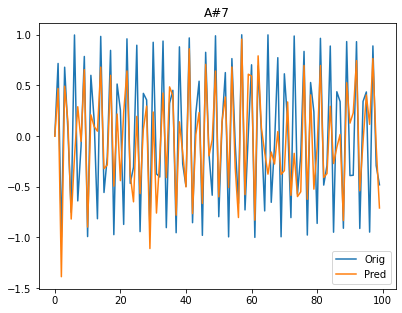

Note: B2
Pred: [-0.218  0.151  0.253  0.307  0.366  0.392  0.449  0.769  0.683  0.717
  0.627  0.868  0.82   0.936  0.641  0.808  1.097  0.862  1.047  0.727
  1.015  0.857  1.086  1.021  0.901  0.911  0.868  0.834  0.834  0.782
  0.717  0.646  0.662  0.737  0.691  0.544  0.446  0.612  0.254  0.389
  0.069  0.168  0.07  -0.107 -0.245 -0.36   0.11  -0.589 -0.593 -0.756
 -0.607  0.016 -0.497 -0.133 -0.973 -0.356 -0.735 -0.927 -1.076 -1.032
 -1.003 -1.002 -0.905 -0.794 -0.908 -0.954 -0.784 -0.503 -0.872 -0.824
 -0.828 -0.702 -0.719 -0.553 -0.15  -0.398 -0.603 -0.59   0.477  0.034
 -0.265 -0.635  0.24  -0.061 -0.294  0.292 -0.294  0.549  0.308  0.644
  0.915  0.628  0.681  1.076  0.575  0.942  0.876  0.847  0.944  0.863]
Orig: [ 0.     0.078  0.155  0.231  0.305  0.378  0.449  0.517  0.582  0.643
  0.7    0.753  0.802  0.846  0.885  0.918  0.946  0.968  0.985  0.995
  1.     0.998  0.991  0.977  0.958  0.933  0.902  0.866  0.825  0.778
  0.727  0.672  0.612  0.549  0.483  0.414  0.342  0.26

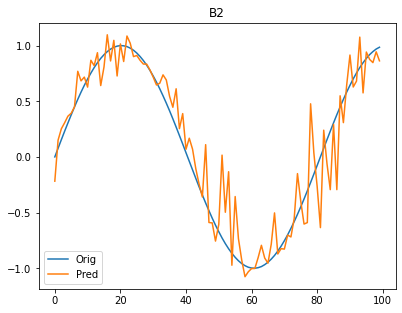

Note: A#2
Pred: [ 0.08   0.112  0.209  0.149  0.229  0.396  0.761  0.808  0.603  0.565
  0.757  0.789  0.616  0.781  0.558  0.841  0.894  0.649  1.026  0.945
  0.698  0.797  0.947  1.01   0.913  0.845  0.915  0.887  0.759  0.924
  0.884  0.698  0.797  0.761  0.686  0.701  0.613  0.36   0.409  0.053
  0.586  0.224  0.342  0.228 -0.129 -0.047  0.113  0.032 -0.314 -0.495
 -0.465 -0.65  -0.284 -0.849 -0.73  -0.669 -0.744 -0.754 -0.908 -0.068
 -0.877 -0.643 -0.73  -0.943 -1.006 -0.766 -0.925 -0.809 -0.976 -0.461
 -0.831 -0.832 -0.931 -0.895 -0.454 -0.701 -0.542 -0.511 -0.825 -0.699
 -0.716 -0.521 -0.273 -0.434 -0.064 -0.173  0.254 -0.362 -0.021  0.157
 -0.049  0.534  0.568  0.422  0.692  0.725  0.6    0.602  0.758  0.783]
Orig: [ 0.     0.073  0.146  0.218  0.289  0.358  0.425  0.49   0.553  0.612
  0.669  0.721  0.77   0.815  0.855  0.89   0.921  0.947  0.968  0.984
  0.994  0.999  0.999  0.994  0.983  0.966  0.945  0.919  0.887  0.851
  0.81   0.765  0.716  0.663  0.607  0.547  0.484  0.4

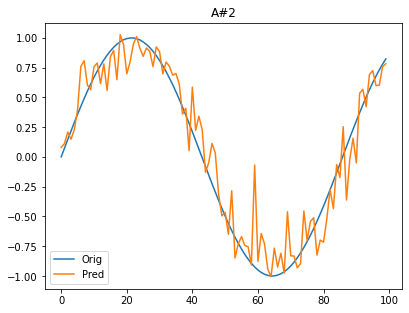

Note: D5
Pred: [-0.082 -0.067  0.492  0.543  1.007  0.812  0.66   0.698  0.07  -0.713
 -0.439 -0.764 -0.555 -0.631 -0.721  0.09  -0.406  0.095  0.045  0.85
  0.89   1.018  1.     0.77   0.959  0.406  0.096 -0.331 -0.535 -0.735
 -1.012 -0.578 -0.508 -0.779 -0.513  0.528  0.558  0.99   0.771  0.562
  0.994  0.353 -0.08  -0.067 -0.495 -0.567 -0.634 -1.063 -0.861 -1.086
  0.104 -0.183  0.781  0.875  0.697  0.922  1.188  0.828  0.697  0.018
  0.164 -0.172  0.013 -0.941 -0.527 -0.865 -0.615 -0.12  -0.207  0.831
  0.659  0.927  0.849  0.609  0.867  0.729  0.426 -0.251 -0.288 -0.721
 -0.78  -0.652 -0.671 -0.728 -0.393 -0.015  0.131  0.73   0.832  0.825
  0.783  0.991  0.853  0.546  0.003 -0.452 -0.968 -1.004 -1.117  0.462]
Orig: [ 0.     0.361  0.673  0.894  0.996  0.963  0.8    0.53   0.188 -0.179
 -0.522 -0.794 -0.96  -0.996 -0.899 -0.68  -0.37  -0.01   0.352  0.666
  0.89   0.995  0.965  0.806  0.538  0.198 -0.169 -0.513 -0.788 -0.957
 -0.997 -0.903 -0.687 -0.379 -0.019  0.343  0.658  0.886

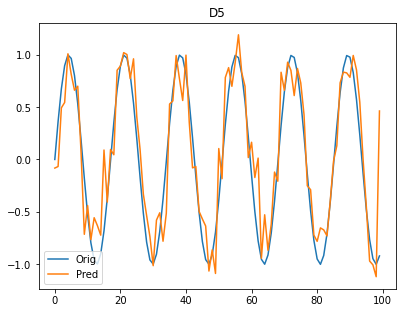

Note: D5
Pred: [ 0.035  0.533  0.792  0.599  0.777  0.808  0.901  0.511  0.123 -0.312
 -0.21  -0.575 -0.817 -0.691 -0.914 -0.348 -0.24   0.493  0.184 -0.065
  0.871  1.054  0.942  0.766  0.429  0.068 -0.108 -0.441 -0.591 -1.115
 -1.077 -0.766 -0.453 -0.437  0.197 -0.21   0.599  0.798  0.716  0.369
  0.888  0.792  0.699 -0.061 -0.461 -0.756 -0.356 -0.939 -0.624 -0.715
 -0.642  0.423  0.864  0.462  0.857  0.991  0.801  0.637  0.599  0.46
  0.176  0.012 -0.292 -0.528 -0.764 -0.983 -0.579 -0.179  0.408  0.583
  0.603  0.661  0.792  0.722  0.688  0.611  0.981  0.222  0.406 -0.929
 -0.842 -0.707  0.844 -0.822 -0.751 -0.092  0.713  0.543  0.943  0.944
  0.942  0.398  0.718  0.286 -0.548 -0.59  -0.592 -0.995 -0.805 -1.201]
Orig: [ 0.     0.361  0.673  0.894  0.996  0.963  0.8    0.53   0.188 -0.179
 -0.522 -0.794 -0.96  -0.996 -0.899 -0.68  -0.37  -0.01   0.352  0.666
  0.89   0.995  0.965  0.806  0.538  0.198 -0.169 -0.513 -0.788 -0.957
 -0.997 -0.903 -0.687 -0.379 -0.019  0.343  0.658  0.886

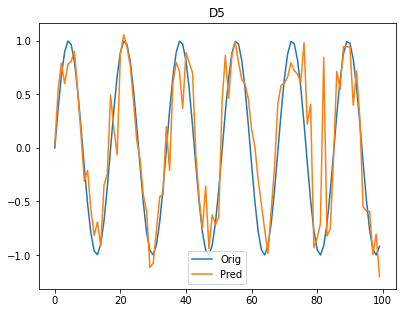

Note: E2
Pred: [ 0.227  0.077  0.146  0.359  0.515  0.224  0.195  0.696  0.358  0.381
  0.511  0.457  0.631  0.79   0.751  0.644  0.63   0.748  0.692  0.881
  0.191  0.882  0.839  0.978  0.828  0.954  0.803  0.955  0.887  1.097
  0.965  1.205  1.099  0.918  1.03   0.916  0.853  0.908  0.929  0.734
  0.838  0.892  0.457  0.746  0.811  0.862  0.675  0.185  0.72   0.614
  0.472  0.293  0.455  0.549  0.38   0.546  0.251  0.294  0.151  0.176
 -0.226 -0.002 -0.19  -0.465 -0.247 -0.322  0.01  -0.428  0.053 -0.569
 -0.632 -0.761 -0.746 -0.566 -0.767 -0.751 -0.826 -0.658 -0.699 -0.62
 -0.988 -0.885 -0.663 -1.008 -0.822 -0.903 -0.979 -0.856 -0.752 -0.837
 -0.827 -0.816 -0.942 -0.935 -1.046 -0.908 -0.981 -0.258 -0.943 -0.88 ]
Orig: [ 0.     0.052  0.103  0.155  0.206  0.256  0.306  0.355  0.402  0.449
  0.495  0.539  0.582  0.623  0.663  0.701  0.737  0.771  0.803  0.833
  0.86   0.885  0.908  0.929  0.947  0.962  0.975  0.985  0.993  0.998
  1.     0.999  0.996  0.991  0.982  0.971  0.957  0.941

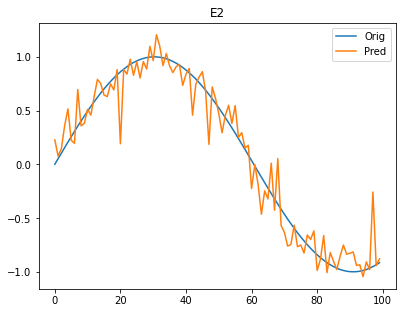

Note: D#2
Pred: [ 0.296  0.024  0.15   0.281  0.403  0.294  0.39   0.302  0.273  0.299
  0.414  0.861  0.625  0.735  0.567  0.756  0.71   0.563  0.807  0.792
  0.604  0.683  0.978  0.2    1.021  0.856  0.854  0.86   0.508  0.971
  0.802  1.039  0.885  0.961  1.067  1.004  0.868  0.715  0.794  0.907
  0.751  0.941  0.754  0.804  0.811  0.755  0.876  0.745  0.599  0.716
  0.718  0.627  0.392  0.401  0.818  0.005  0.588  0.214  0.574  0.369
 -0.04   0.264 -0.046 -0.106  0.167  0.027 -0.185 -0.368 -0.206 -0.463
 -0.256 -0.164 -0.151 -0.488 -0.037 -0.344 -0.448 -0.783 -0.621 -0.127
 -0.798 -0.932 -0.733 -0.837 -0.862 -0.853 -0.974 -1.013 -0.788 -0.768
 -0.924 -0.771 -0.777 -0.864 -0.932 -0.999 -1.079 -0.821 -0.916 -1.055]
Orig: [ 0.     0.049  0.098  0.146  0.194  0.242  0.289  0.335  0.381  0.426
  0.469  0.512  0.553  0.593  0.632  0.669  0.705  0.738  0.771  0.801
  0.829  0.855  0.88   0.902  0.922  0.94   0.955  0.969  0.98   0.988
  0.995  0.998  1.     0.999  0.996  0.99   0.982  0.9

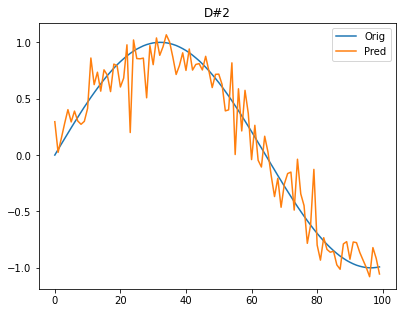

In [7]:
import matplotlib.pyplot as plt

# evaluation
for _ in np.random.randint(0, len(ds_freqs), size=10):
    note_id, orig_wave = ds_freqs[_]
    pred_wave = Model(note_id.unsqueeze(0)).squeeze(0)

    pred = np.round(pred_wave[:100].detach().numpy(), 3)
    orig = np.round(orig_wave[:100].numpy(), 3)

    print(f"Note: {Notes[note_id.item()]}")
    print(f"Pred: {str(pred):<30}")
    print(f"Orig: {orig}")

    plt.plot(orig, label="Orig")
    plt.plot(pred, label="Pred")
    plt.legend()
    plt.title(Notes[note_id.item()])
    plt.show()

We see reasonable matches with some jitter. The jitter is particularly pronounced lower frequency notes like A#2 and D#2. This may be because the model is using MSE which does not in itself encourage sinusoidal smoothing and because the lower frequency notes have longer sine periods, which suggests increasting the sequence length even more might help reduce the jitter.

# Problem 3

To take multiple added sound generations and make a chord we would need to change the model to take multiple note tokens as input and produce a waveform that represents the sum of their sine waves.

For example, we could generate the individual sine waves for C4, E4, and G4 using their frequencies, then add them pointwise across time to get the intended output.

The dataset would change from (single_note_id, waveform) to (list_of_note_ids, combined_waveform), where the target waveform would be the additive mixture of the component notes. The input representation could be formed by embedding each note in the chord and then combining those embeddings through summing the note sequence through a transformer encoder, so the model can learn relationships among the notes. 

The decoder would generate the full waveform conditioned on that combined representation. 

For example, for a C major chord, the target would be a sequence like $sin(2\pi f_{C4} t) + sin(2 \pi f_{E4} t) + sin(2 \pi f_{G4} t)$, possibly scaled in some way to avoid clipping. 

This would work because, acoustically, a chord is the superposition of multiple frequencies sounding at the same time, so additive waveform generation is a feasible way to extend our single-note synthesis to a multi-note harmony.